In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('fraud.csv')

In [3]:
df.head()

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0


In [4]:
df = df.replace("'", "", regex=True)

# **Data Validation**

In [5]:
df[df['amount']==0]  

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
40502,15,C1918953803,2,F,28007,M348934600,28007,es_transportation,0.0,0
46361,17,C782199851,2,F,28007,M348934600,28007,es_transportation,0.0,0
48560,18,C92282564,3,F,28007,M348934600,28007,es_transportation,0.0,0
64613,24,C612357573,6,M,28007,M348934600,28007,es_transportation,0.0,0
84320,31,C1299474405,4,F,28007,M348934600,28007,es_transportation,0.0,0
87713,32,C1814870538,3,M,28007,M1823072687,28007,es_transportation,0.0,0
88889,32,C1189224644,2,M,28007,M1823072687,28007,es_transportation,0.0,0
89155,32,C1598762673,3,M,28007,M1823072687,28007,es_transportation,0.0,0
127028,45,C876944738,2,F,28007,M1823072687,28007,es_transportation,0.0,0
133555,47,C73919470,3,F,28007,M348934600,28007,es_transportation,0.0,0


In [6]:
c_list = df[df['amount'] == 0]['customer'].unique().tolist()

df[df['customer'].isin(c_list)]['fraud'].value_counts()

fraud
0    8416
1      37
Name: count, dtype: int64

In [7]:
df['has_zero_amount_transaction'] = df['customer'].isin(c_list).astype(int)

In [8]:
df[df['step'] < 0]

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud,has_zero_amount_transaction


In [9]:
# misspelling
columns_to_check = ['gender','category']

for i in columns_to_check:
  print(f'column {i}')
  print(df[i].value_counts())
  print("********************************")

column gender
gender
F    324565
M    268385
E      1178
U       515
Name: count, dtype: int64
********************************
column category
category
es_transportation        505119
es_food                   26254
es_health                 16133
es_wellnessandbeauty      15086
es_fashion                 6454
es_barsandrestaurants      6373
es_hyper                   6098
es_sportsandtoys           4002
es_tech                    2370
es_home                    1986
es_hotelservices           1744
es_otherservices            912
es_contents                 885
es_travel                   728
es_leisure                  499
Name: count, dtype: int64
********************************


# **Handle Missing Values**

In [10]:
df.isna().sum()

step                           0
customer                       0
age                            0
gender                         0
zipcodeOri                     0
merchant                       0
zipMerchant                    0
category                       0
amount                         0
fraud                          0
has_zero_amount_transaction    0
dtype: int64

In [11]:
for i in df.columns:
  print("_______________________________________")
  print(f"unique values for column {i}")
  print(df[i].unique())
  print("_______________________________________")
  print()

_______________________________________
unique values for column step
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179]
_______________________________________

_______________________________________
unique values for column customer
['C1093826151' 'C352968107' 'C2054744914' ... 'C1014783484' 'C849065220'
 'C18096462

In [12]:
# when the gender is unknown all frausd transaction is labled as 0 so we can simply remove them 
# aslo they are 515 rows so we have a lot of data 
print(df[df['gender'] == 'U'].shape)
print('-------------------------------')
df[df['gender'] == 'U']['fraud'].unique()

(515, 11)
-------------------------------


array([0])

In [13]:
df[df['gender'] == 'U']

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud,has_zero_amount_transaction
586,0,C885208928,1,U,28007,M348934600,28007,es_transportation,28.57,0,0
828,0,C935791733,3,U,28007,M1823072687,28007,es_transportation,33.12,0,0
1849,0,C824676284,2,U,28007,M348934600,28007,es_transportation,48.72,0,0
4788,1,C935791733,3,U,28007,M85975013,28007,es_food,62.87,0,0
6010,2,C935791733,3,U,28007,M1053599405,28007,es_health,9.65,0,0
...,...,...,...,...,...,...,...,...,...,...,...
587122,177,C885208928,1,U,28007,M1823072687,28007,es_transportation,1.13,0,0
587356,178,C885208928,1,U,28007,M1823072687,28007,es_transportation,3.20,0,0
589685,178,C824676284,2,U,28007,M1823072687,28007,es_transportation,11.38,0,0
589808,178,C935791733,3,U,28007,M1823072687,28007,es_transportation,12.25,0,0


In [14]:
df = df[df['gender'] != 'U']

In [15]:
df[(df['age'] == 'U') & (df['fraud'] == 1)]

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud,has_zero_amount_transaction
284816,94,C1208164294,U,E,28007,M480139044,28007,es_health,371.84,1,0
307900,100,C2075935351,U,E,28007,M2122776122,28007,es_home,1215.63,1,0
325728,106,C1871125244,U,E,28007,M855959430,28007,es_hyper,434.17,1,0
327868,106,C1215440829,U,E,28007,M78078399,28007,es_wellnessandbeauty,197.14,1,0
435065,136,C1208164294,U,E,28007,M1294758098,28007,es_leisure,462.97,1,0
455738,142,C1215440829,U,E,28007,M1198415165,28007,es_wellnessandbeauty,338.26,1,0
549529,167,C1871125244,U,E,28007,M1888755466,28007,es_otherservices,294.20,1,0


In [16]:
df[(df['age'] == 'U') & (df['fraud'] == 1)]['customer'].unique().tolist()

['C1208164294', 'C2075935351', 'C1871125244', 'C1215440829']

In [17]:
df[df['gender'] == 'E']['fraud'].value_counts()

fraud
0    1171
1       7
Name: count, dtype: int64

In [18]:
df[df['customer'].isin(df[(df['age'] == 'U') & (df['fraud'] == 1)]['customer'].unique().tolist())]['gender'].unique()

array(['E'], dtype=object)

In [19]:
df[df['age'] == 'U']['gender'].unique()

array(['E'], dtype=object)

In [20]:
# when age is unknown it's all Enterprise so logically we should keep them 

In [21]:
df[df['age'] == 'U']

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud,has_zero_amount_transaction
467,0,C2075935351,U,E,28007,M1823072687,28007,es_transportation,21.25,0,0
1493,0,C914000857,U,E,28007,M348934600,28007,es_transportation,35.59,0,0
1855,0,C808326652,U,E,28007,M348934600,28007,es_transportation,56.78,0,1
2091,0,C1374607221,U,E,28007,M1823072687,28007,es_transportation,17.47,0,0
2795,1,C1871125244,U,E,28007,M547558035,28007,es_fashion,40.38,0,0
...,...,...,...,...,...,...,...,...,...,...,...
592375,179,C1215440829,U,E,28007,M1823072687,28007,es_transportation,44.16,0,0
592594,179,C2075935351,U,E,28007,M1823072687,28007,es_transportation,16.78,0,0
593660,179,C1871125244,U,E,28007,M1823072687,28007,es_transportation,56.11,0,0
594128,179,C1374607221,U,E,28007,M1823072687,28007,es_transportation,4.44,0,0


# **EDA**

In [22]:
# Every merchant has one category
df.groupby(['merchant'])['category'].nunique()

merchant
M1053599405    1
M117188757     1
M1198415165    1
M1294758098    1
M1313686961    1
M1352454843    1
M1353266412    1
M1400236507    1
M1416436880    1
M151143676     1
M1535107174    1
M1600850729    1
M1649169323    1
M1726401631    1
M17379832      1
M1741626453    1
M1748431652    1
M1788569036    1
M1823072687    1
M1842530320    1
M1872033263    1
M1873032707    1
M1888755466    1
M1913465890    1
M1946091778    1
M2011752106    1
M2080407379    1
M209847108     1
M2122776122    1
M348875670     1
M348934600     1
M349281107     1
M3697346       1
M45060432      1
M480139044     1
M495352832     1
M50039827      1
M547558035     1
M677738360     1
M692898500     1
M732195782     1
M78078399      1
M840466850     1
M855959430     1
M857378720     1
M85975013      1
M923029380     1
M933210764     1
M97925176      1
M980657600     1
Name: category, dtype: int64

In [23]:
mdf = df.groupby(['merchant', 'category']).agg(number_customer=('customer', 'nunique'),
                                        number_transaction=('customer', 'count'),fraud_1=('fraud', 'sum') ).reset_index()


mdf['fraud_0'] = mdf['number_transaction'] - mdf['fraud_1']

mdf['fraud_pct_per_merchant'] =  (mdf['fraud_1'] / mdf['number_transaction']) * 100
mdf = mdf.sort_values('fraud_pct_per_merchant', ascending=False)


In [24]:
fig = px.bar(mdf,x="merchant",y="fraud_pct_per_merchant",
    hover_data=["number_customer", "number_transaction", "fraud_1", "fraud_0"],
    title="Fraud Percentage per Merchant", labels={"fraud_pct_per_merchant": "fraud percentage", "number_customer": '# of customers' ,'number_transaction':'# of transactions', 'fraud_1':'fraud' , 'fraud_0' : 'not fraud'})

fig.update_layout(width = 1100,height=530)

fig.show()


In [25]:
def assign_risk(fraud_pct):
    if fraud_pct == 0:
        return 'no_risk'
    elif fraud_pct >= 50:
        return 'high_risk'
    elif fraud_pct >= 20:
        return 'medium_risk'
    else:
        return 'low_risk'

mdf['risk_level'] = mdf['fraud_pct_per_merchant'].apply(assign_risk)

In [26]:
df = df.merge(mdf[['merchant','risk_level']],on = 'merchant', how = 'left')

In [27]:

fig = px.bar(mdf,x="merchant",y="fraud_pct_per_merchant",color="category",
    hover_data=["number_customer", "number_transaction", "fraud_1", "fraud_0"],
    title="Fraud Percentage per Merchant And Category", labels={"fraud_pct_per_merchant": "fraud percentage", "number_customer": '# of customers' ,'number_transaction':'# of transactions', 'fraud_1':'fraud' , 'fraud_0' : 'not fraud'})
fig.show()


In [28]:
# distribution of the target variable

fraud_counts = df['fraud'].astype(str).value_counts().reset_index()
fraud_counts.columns = ['fraud', 'count']

fig = px.bar(fraud_counts, x='fraud', y='count', title="Fraud Distribution",text='count',)
fig.update_xaxes(tickvals=['0', '1'],ticktext=['no', 'yes'])
fig.update_layout( height=530)

fig.show()

In [29]:
fig = px.box(df,x="fraud",y="amount",color="fraud",color_discrete_map={0: "blue", 1: "red"},title="Transaction Amounts by Fraud Status")

fig.update_layout(height=530)

fig.show()

In [30]:
amount_per_cat = df[df['fraud'] == 1].groupby('category')['amount'].sum().reset_index().sort_values(by = 'amount', ascending = False).reset_index(drop = True)

In [31]:
amount_per_cat

,category,amount
0,es_travel,1537944.06
1,es_health,690325.15
2,es_sportsandtoys,684517.02
3,es_hotelservices,231159.19
4,es_wellnessandbeauty,164725.38
5,es_leisure,142335.98
6,es_home,138160.42
7,es_otherservices,72155.07
8,es_tech,65613.31
9,es_hyper,47391.52


In [32]:
fig = px.bar(amount_per_cat,x='category',y='amount',title='Fraud Transaction Amount by Category',text='amount')
fig.update_traces(textposition='outside')
fig.update_layout(yaxis=dict(title=''),xaxis=dict(title='Total Fraud Amount'),margin=dict(l=150),height = 570)
fig.show()

In [33]:
fraud_df = df[df['fraud'] == 1]
non_fraud_df = df[df['fraud'] == 0]

In [34]:
def make_sub_plots(fraud_data, non_fraud_data , title ):
  fig = make_subplots(rows=1, cols=2, subplot_titles=("Fraud Transactions", "Non Fraud Transactions"))

  fig.add_trace(go.Bar(x=fraud_data.index, y=fraud_data.values, marker_color='red', name='Fraud'),row=1, col=1)
  fig.add_trace(go.Bar(x=non_fraud_data.index, y=non_fraud_data.values, marker_color='green', name='Non-Fraud'),row=1, col=2)

  fig.update_layout(title_text=title,showlegend=False)

  fig.show()

In [35]:
fraud_gender_counts = fraud_df['gender'].value_counts()
non_fraud_gender_counts = non_fraud_df['gender'].value_counts()

make_sub_plots(fraud_gender_counts, non_fraud_gender_counts , 'Transaction by Gender')

In [36]:
pivot = df.pivot_table(index='gender', columns='fraud', aggfunc='size', fill_value=0)
pivot.columns = ['non_fraud', 'fraud']

pivot['total_transaction'] = pivot['non_fraud'] + pivot['fraud']
pivot['fraud_percentage'] = (pivot['fraud'] / pivot['total_transaction']) * 100

In [37]:
pivot

,non_fraud,fraud,total_transaction,fraud_percentage
gender,,,,
E,1171,7,1178,0.594228
F,319807,4758,324565,1.465962
M,265950,2435,268385,0.907279


In [38]:
cdf = df.groupby(['customer'], as_index=False).agg(
    number_merchant=pd.NamedAgg(column='merchant', aggfunc='nunique'),
    number_transaction=pd.NamedAgg(column='merchant', aggfunc='count'),
    fraud_1=pd.NamedAgg(column="fraud", aggfunc=lambda x: (x == 1).sum()),
    fraud_0=pd.NamedAgg(column="fraud", aggfunc=lambda x: (x == 0).sum()))
cdf['fraud_pct_per_customer'] = (cdf['fraud_1'] / cdf['number_transaction']) * 100

cdf = cdf.sort_values(by = 'fraud_pct_per_customer', ascending = False)
cdf

,customer,number_merchant,number_transaction,fraud_1,fraud_0,fraud_pct_per_customer
3924,C910454738,22,92,87,5,94.565217
2187,C2004941826,24,126,119,7,94.444444
2816,C381007057,22,100,89,11,89.000000
1249,C1572610482,23,101,89,12,88.118812
3308,C617723960,20,46,40,6,86.956522
...,...,...,...,...,...,...
1280,C1587738251,12,176,0,176,0.000000
1283,C1590346257,8,169,0,169,0.000000
1284,C1591008232,10,168,0,168,0.000000
1269,C1580955370,14,172,0,172,0.000000


In [39]:
df['customer'].nunique()

4109

In [40]:
fraud_customers = set(fraud_df['customer'].unique().tolist())
non_fraud_customers = set(non_fraud_df['customer'].unique().tolist())
df[df['customer'].isin(non_fraud_customers.difference(fraud_customers))]

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud,has_zero_amount_transaction,risk_level
0,0,C1093826151,4,M,28007,M348934600,28007,es_transportation,4.55,0,0,no_risk
1,0,C352968107,2,M,28007,M348934600,28007,es_transportation,39.68,0,0,no_risk
2,0,C2054744914,4,F,28007,M1823072687,28007,es_transportation,26.89,0,0,no_risk
3,0,C1760612790,3,M,28007,M348934600,28007,es_transportation,17.25,0,0,no_risk
4,0,C757503768,5,M,28007,M348934600,28007,es_transportation,35.72,0,0,no_risk
...,...,...,...,...,...,...,...,...,...,...,...,...
594121,179,C1904086644,5,F,28007,M1823072687,28007,es_transportation,28.93,0,0,no_risk
594123,179,C1753498738,3,F,28007,M1823072687,28007,es_transportation,20.53,0,0,no_risk
594124,179,C650108285,4,F,28007,M1823072687,28007,es_transportation,50.73,0,0,no_risk
594126,179,C1499363341,5,M,28007,M1823072687,28007,es_transportation,14.46,0,0,no_risk


In [41]:
customers_with_no_fraud = non_fraud_customers.difference(fraud_customers)

first_ten_customers = list(customers_with_no_fraud)[:10]

top_customers =  pd.DataFrame({"customer": first_ten_customers,"count": [1]*len(first_ten_customers)})

fig = px.pie(top_customers, names="customer", values="count", title="Customers with No Fraud")
fig.update_traces(textinfo='label')

fig.show()

In [42]:
df[df['customer'].isin(c_list)]['fraud'].value_counts()

fraud
0    8416
1      37
Name: count, dtype: int64

In [43]:
customers_0 = df[(df['customer'].isin(c_list)) & (df['fraud'] == 1)]['customer'].unique()

In [44]:
df[df['customer'].isin(customers_0)]['fraud'].value_counts()

fraud
0    2466
1      37
Name: count, dtype: int64

In [45]:
customers_0_df = df[df['customer'].isin(customers_0)]

In [46]:
customers_0_df.sort_values(by = ['customer','step'])

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud,has_zero_amount_transaction,risk_level
10426,4,C1007572087,2,F,28007,M1888755466,28007,es_otherservices,122.20,0,1,medium_risk
80518,30,C1007572087,2,F,28007,M855959430,28007,es_hyper,6.69,0,1,low_risk
84901,31,C1007572087,2,F,28007,M348934600,28007,es_transportation,36.89,0,1,no_risk
89417,33,C1007572087,2,F,28007,M348934600,28007,es_transportation,57.05,0,1,no_risk
92098,33,C1007572087,2,F,28007,M480139044,28007,es_health,794.96,1,1,medium_risk
...,...,...,...,...,...,...,...,...,...,...,...,...
579044,175,C833126375,4,M,28007,M1823072687,28007,es_transportation,18.96,0,1,no_risk
581846,176,C833126375,4,M,28007,M1823072687,28007,es_transportation,30.52,0,1,no_risk
585542,177,C833126375,4,M,28007,M1823072687,28007,es_transportation,1.84,0,1,no_risk
588469,178,C833126375,4,M,28007,M1823072687,28007,es_transportation,6.37,0,1,no_risk


In [47]:
for i in customers_0_df.customer.unique().tolist():
    filtered_df = customers_0_df[customers_0_df['customer'] == i]

    index = filtered_df.index
    if filtered_df.loc[index[0], 'fraud'] == 0:
        customers_0_df.loc[index , 'fraud_after_zero'] = 1
    else:
        customers_0_df.loc[index , 'fraud_after_zero'] = 0

In [48]:
after_zero_fraud = pd.DataFrame(customers_0_df['fraud_after_zero'].value_counts()).reset_index()
after_zero_fraud['fraud_after_zero'] = after_zero_fraud['fraud_after_zero'].replace({1.0:'Yes' , 0.0:'No'})

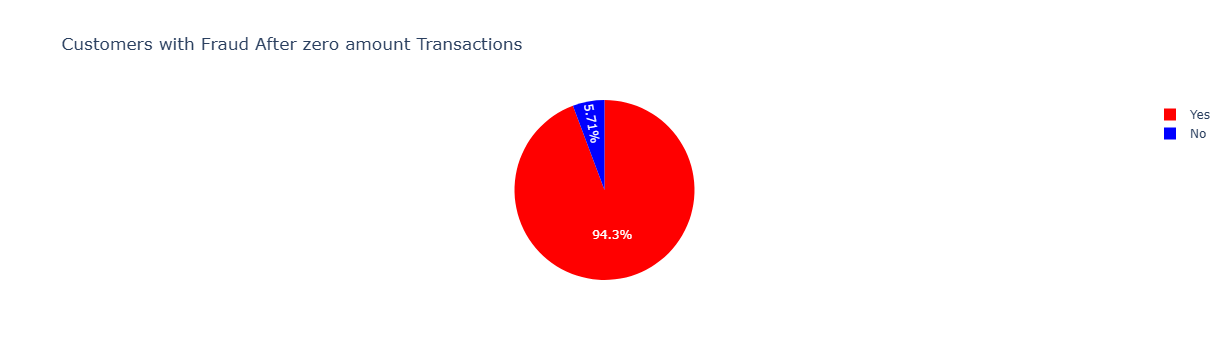

In [49]:
fig = px.pie(after_zero_fraud, names="fraud_after_zero", values="count", title="Customers with Fraud After zero amount Transactions",
             color="fraud_after_zero", color_discrete_map={"Yes": "red", "No": "blue"})


fig.show()

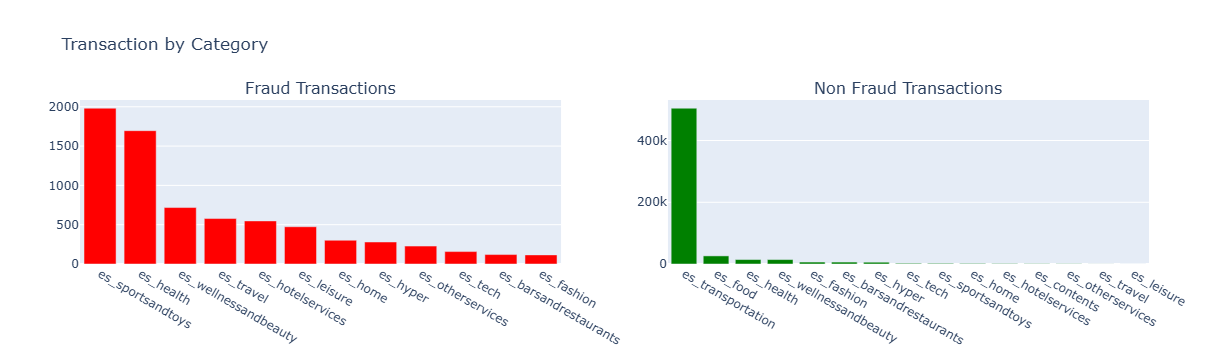

In [50]:
fraud_category_counts = fraud_df['category'].value_counts()
non_fraud_category_counts = non_fraud_df['category'].value_counts()

make_sub_plots(fraud_category_counts, non_fraud_category_counts , 'Transaction by Category')

In [51]:
fraud_cat = set(fraud_df['category'].unique().tolist())
non_fraud_cat = set(non_fraud_df['category'].unique().tolist())
non_fraud_cat.difference(fraud_cat)

{'es_contents', 'es_food', 'es_transportation'}

In [52]:
def count_category(columns):
    counts = df.groupby(columns).size().reset_index(name='count')

    pivot = counts.pivot(index=columns[0], columns=columns[1], values='count').fillna(0)
    
    pivot.columns = ['non_fraud', 'fraud']
    pivot['fraud_pct'] = pivot['fraud'] / (pivot['fraud'] + pivot['non_fraud']) * 100
    pivot = pivot.reset_index().sort_values(by = 'fraud_pct', ascending=False)
    return pivot
    

In [53]:
category_pivot = count_category(['category', 'fraud'])

In [54]:
category_pivot

,category,non_fraud,fraud,fraud_pct
8,es_leisure,25.0,474.0,94.989980
13,es_travel,150.0,578.0,79.395604
10,es_sportsandtoys,2020.0,1982.0,49.525237
6,es_hotelservices,1196.0,548.0,31.422018
9,es_otherservices,684.0,228.0,25.000000
5,es_home,1682.0,302.0,15.221774
4,es_health,14416.0,1696.0,10.526316
11,es_tech,2207.0,158.0,6.680761
14,es_wellnessandbeauty,14363.0,718.0,4.760957
7,es_hyper,5816.0,280.0,4.593176


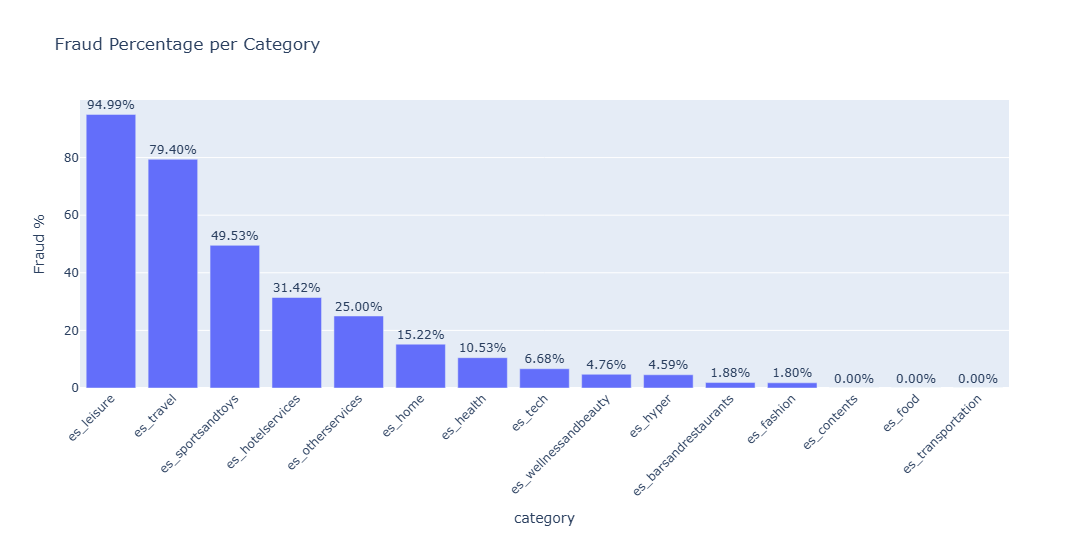

In [55]:
fig = px.bar(category_pivot,x='category',y='fraud_pct',text='fraud_pct',title='Fraud Percentage per Category',labels={'fraud_pct': 'Fraud percentage'})

fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig.update_layout(xaxis_tickangle=-45, height=535, yaxis=dict(title='Fraud %'))

fig.show()

In [56]:
df[df['category'] == 'es_leisure']['fraud'].value_counts()

fraud
1    474
0     25
Name: count, dtype: int64

In [57]:
df[df['category'] == 'es_leisure']['fraud'].value_counts()

fraud
1    474
0     25
Name: count, dtype: int64

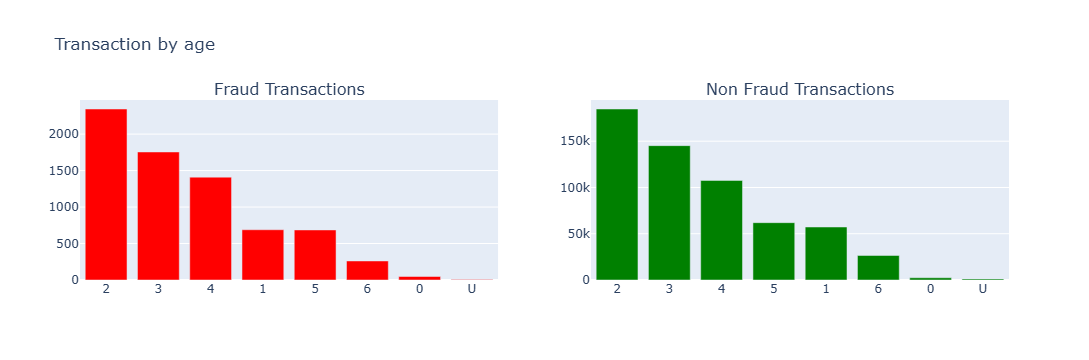

In [58]:
fraud_category_counts = fraud_df['age'].value_counts()
non_fraud_category_counts = non_fraud_df['age'].value_counts()

make_sub_plots(fraud_category_counts, non_fraud_category_counts , 'Transaction by age')

In [59]:
age_pivot = count_category(['age', 'fraud'])
age_pivot

,age,non_fraud,fraud,fraud_pct
0,0,2404,48,1.957586
4,4,107615,1410,1.293281
2,2,184802,2344,1.252498
3,3,145203,1755,1.194219
1,1,57264,689,1.188894
5,5,61956,686,1.095112
6,6,26513,261,0.974826
7,U,1171,7,0.594228


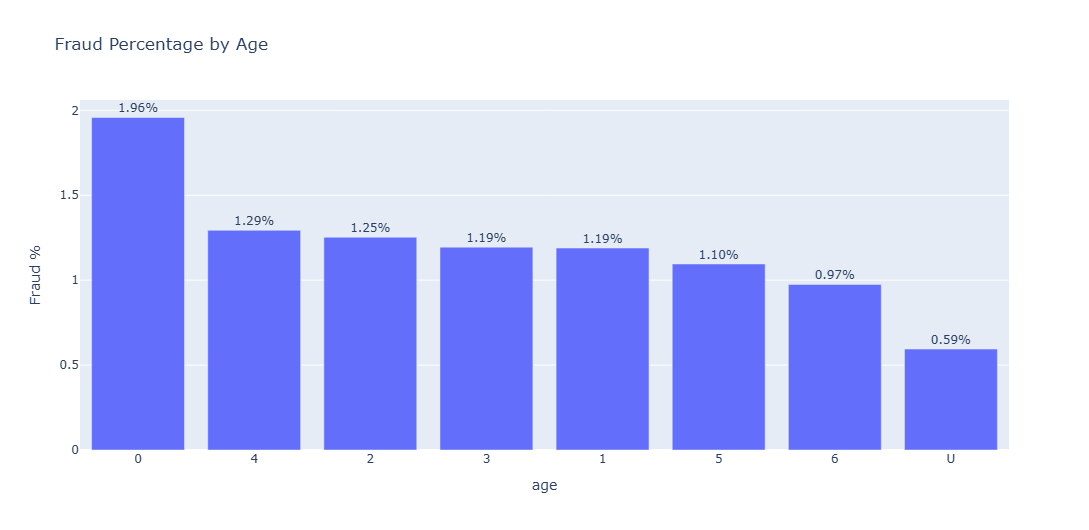

In [60]:
fig = px.bar(age_pivot,x='age',y='fraud_pct',text='fraud_pct',title='Fraud Percentage by Age',labels={'fraud_pct': 'Fraud percentage'})

fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig.update_layout(height=530, yaxis=dict(title='Fraud %'))

fig.show()

In [61]:
df["hour"] = df["step"] % 24

def get_time_of_day(hour):
    if 5 <= hour < 12:
        return "morning"
    elif 12 <= hour < 17:
        return "afternoon"
    elif 17 <= hour < 21:
        return "evening"
    else:
        return "night"

df["time_of_day"] = df["hour"].apply(get_time_of_day)

df

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud,has_zero_amount_transaction,risk_level,hour,time_of_day
0,0,C1093826151,4,M,28007,M348934600,28007,es_transportation,4.55,0,0,no_risk,0,night
1,0,C352968107,2,M,28007,M348934600,28007,es_transportation,39.68,0,0,no_risk,0,night
2,0,C2054744914,4,F,28007,M1823072687,28007,es_transportation,26.89,0,0,no_risk,0,night
3,0,C1760612790,3,M,28007,M348934600,28007,es_transportation,17.25,0,0,no_risk,0,night
4,0,C757503768,5,M,28007,M348934600,28007,es_transportation,35.72,0,0,no_risk,0,night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594123,179,C1753498738,3,F,28007,M1823072687,28007,es_transportation,20.53,0,0,no_risk,11,morning
594124,179,C650108285,4,F,28007,M1823072687,28007,es_transportation,50.73,0,0,no_risk,11,morning
594125,179,C123623130,2,F,28007,M349281107,28007,es_fashion,22.44,0,0,no_risk,11,morning
594126,179,C1499363341,5,M,28007,M1823072687,28007,es_transportation,14.46,0,0,no_risk,11,morning


In [62]:
fraud_time_counts = df[df['fraud'] == 1]['time_of_day'].value_counts()
nonfraud_time_counts = df[df['fraud'] == 0]['time_of_day'].value_counts()

In [63]:
df[df['fraud'] == 1]['time_of_day'].value_counts()

time_of_day
night        2440
morning      2240
afternoon    1400
evening      1120
Name: count, dtype: int64

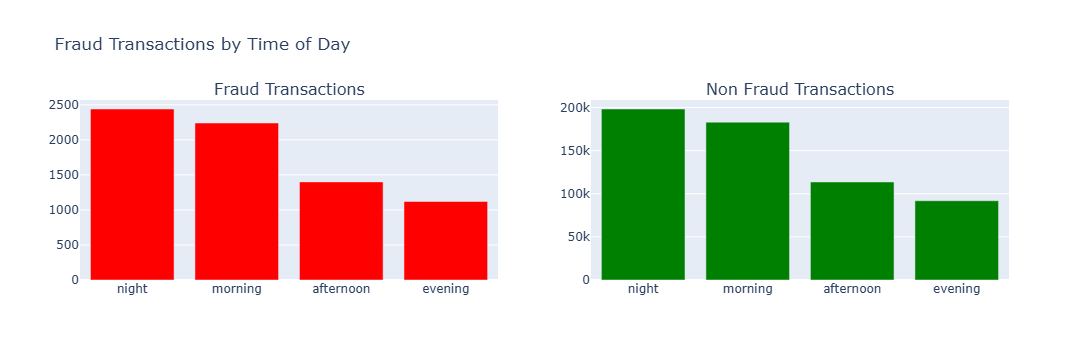

In [64]:
make_sub_plots(fraud_time_counts, nonfraud_time_counts, 'Fraud Transactions by Time of Day')


In [65]:
df

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud,has_zero_amount_transaction,risk_level,hour,time_of_day
0,0,C1093826151,4,M,28007,M348934600,28007,es_transportation,4.55,0,0,no_risk,0,night
1,0,C352968107,2,M,28007,M348934600,28007,es_transportation,39.68,0,0,no_risk,0,night
2,0,C2054744914,4,F,28007,M1823072687,28007,es_transportation,26.89,0,0,no_risk,0,night
3,0,C1760612790,3,M,28007,M348934600,28007,es_transportation,17.25,0,0,no_risk,0,night
4,0,C757503768,5,M,28007,M348934600,28007,es_transportation,35.72,0,0,no_risk,0,night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594123,179,C1753498738,3,F,28007,M1823072687,28007,es_transportation,20.53,0,0,no_risk,11,morning
594124,179,C650108285,4,F,28007,M1823072687,28007,es_transportation,50.73,0,0,no_risk,11,morning
594125,179,C123623130,2,F,28007,M349281107,28007,es_fashion,22.44,0,0,no_risk,11,morning
594126,179,C1499363341,5,M,28007,M1823072687,28007,es_transportation,14.46,0,0,no_risk,11,morning


# **Data Preparation for ML Models**

In [66]:
df.head()

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud,has_zero_amount_transaction,risk_level,hour,time_of_day
0,0,C1093826151,4,M,28007,M348934600,28007,es_transportation,4.55,0,0,no_risk,0,night
1,0,C352968107,2,M,28007,M348934600,28007,es_transportation,39.68,0,0,no_risk,0,night
2,0,C2054744914,4,F,28007,M1823072687,28007,es_transportation,26.89,0,0,no_risk,0,night
3,0,C1760612790,3,M,28007,M348934600,28007,es_transportation,17.25,0,0,no_risk,0,night
4,0,C757503768,5,M,28007,M348934600,28007,es_transportation,35.72,0,0,no_risk,0,night


In [67]:
df['risk_level'].unique()

array(['no_risk', 'low_risk', 'medium_risk', 'high_risk'], dtype=object)

In [71]:
df['risk_level'] = df['risk_level'].replace({'no_risk':0 ,'low_risk' :1 ,'medium_risk':2 , 'high_risk':3})

In [72]:
df_encoded = pd.get_dummies(df, columns=['gender', 'category'], drop_first=False)
df_encoded

,step,customer,age,zipcodeOri,merchant,zipMerchant,amount,fraud,has_zero_amount_transaction,risk_level,...,category_es_home,category_es_hotelservices,category_es_hyper,category_es_leisure,category_es_otherservices,category_es_sportsandtoys,category_es_tech,category_es_transportation,category_es_travel,category_es_wellnessandbeauty
0,0,C1093826151,4,28007,M348934600,28007,4.55,0,0,0,...,False,False,False,False,False,False,False,True,False,False
1,0,C352968107,2,28007,M348934600,28007,39.68,0,0,0,...,False,False,False,False,False,False,False,True,False,False
2,0,C2054744914,4,28007,M1823072687,28007,26.89,0,0,0,...,False,False,False,False,False,False,False,True,False,False
3,0,C1760612790,3,28007,M348934600,28007,17.25,0,0,0,...,False,False,False,False,False,False,False,True,False,False
4,0,C757503768,5,28007,M348934600,28007,35.72,0,0,0,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594123,179,C1753498738,3,28007,M1823072687,28007,20.53,0,0,0,...,False,False,False,False,False,False,False,True,False,False
594124,179,C650108285,4,28007,M1823072687,28007,50.73,0,0,0,...,False,False,False,False,False,False,False,True,False,False
594125,179,C123623130,2,28007,M349281107,28007,22.44,0,0,0,...,False,False,False,False,False,False,False,False,False,False
594126,179,C1499363341,5,28007,M1823072687,28007,14.46,0,0,0,...,False,False,False,False,False,False,False,True,False,False


In [114]:

X = df_encoded.drop(columns=['fraud','customer','age','zipcodeOri','zipMerchant','merchant','time_of_day','hour','step'])
y = df_encoded['fraud']

smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

df_resampled = pd.concat([pd.DataFrame(X_resampled, columns=X.columns),
                          pd.DataFrame(y_resampled, columns=['fraud'])],
                         axis=1)


In [115]:
df_resampled['fraud'].value_counts()

fraud
0    586928
1    586928
Name: count, dtype: int64

In [116]:
df_resampled.shape

(1173856, 22)

# **Building Models**

In [117]:
def build_nn(input_dim):
  model = Sequential([
      Dense(32, activation='relu', input_shape=(input_dim,)),
      Dense(16, activation='relu'),
      Dense(1, activation='sigmoid') 
  ])
  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [118]:
models = {
    "random_forest": RandomForestClassifier(),
    "gradient_boosting": GradientBoostingClassifier(),
    "logistic_regression": LogisticRegression(),
    "neural_network": build_nn
}


In [119]:
scalers = {"none": '',"min_max_scaler": MinMaxScaler(),"standard_scaler": StandardScaler()}

In [120]:
features = df_resampled.drop(columns=['fraud'])
target = df_resampled['fraud']

In [121]:
# split the data 
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, shuffle=True)

In [122]:
y_test.value_counts()

fraud
0    176313
1    175844
Name: count, dtype: int64

In [123]:
y_train.value_counts()

fraud
1    411084
0    410615
Name: count, dtype: int64

In [124]:
results_list = []

numeric_cols = ['amount']

for scaler_name, scaler in scalers.items():
    if scaler_name == "none":
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()
    else:
        scaler.set_output(transform="pandas")
        
        X_train_num_scaled = scaler.fit_transform(X_train[numeric_cols])
        X_test_num_scaled = scaler.transform(X_test[numeric_cols])
        
        X_train_scaled = pd.concat([X_train.drop(columns=numeric_cols), X_train_num_scaled], axis=1)
        X_test_scaled = pd.concat([X_test.drop(columns=numeric_cols), X_test_num_scaled], axis=1)

    for model_name, model in models.items():
        print(f"training model {model_name} with {scaler_name}")
        
        if model_name == "neural_network":
            nn_model = model(X_train_scaled.shape[1])
            nn_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=0)
            y_pred_prob = nn_model.predict(X_test_scaled)
            y_pred = (y_pred_prob > 0.5).astype(int).flatten()
            feature_importance = None
        else:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)

            if hasattr(model, "feature_importances_"):
                feature_importance = dict(zip(X_train_scaled.columns, model.feature_importances_))
            elif hasattr(model, "coef_"):
                feature_importance = dict(zip(X_train_scaled.columns, model.coef_.flatten()))
            else:
                feature_importance = None

        f1 = f1_score(y_test, y_pred)

        results_list.append({
            "model": model_name,
            "scaler": scaler_name,
            "f1 Score": f1,
            "feature_importance": feature_importance
        })

results = pd.DataFrame(results_list)


training model random_forest with none
training model gradient_boosting with none
training model logistic_regression with none
training model neural_network with none
11005/11005 ━━━━━━━━━━━━━━━━━━━━ 7s 615us/step
training model random_forest with min_max_scaler
training model gradient_boosting with min_max_scaler
training model logistic_regression with min_max_scaler
training model neural_network with min_max_scaler
11005/11005 ━━━━━━━━━━━━━━━━━━━━ 7s 673us/step
training model random_forest with standard_scaler
training model gradient_boosting with standard_scaler
training model logistic_regression with standard_scaler
training model neural_network with standard_scaler
11005/11005 ━━━━━━━━━━━━━━━━━━━━ 7s 602us/step


In [125]:
results

,model,scaler,f1 Score,feature_importance
0,random_forest,none,0.991079,"{'amount': 0.2275386408980701, 'has_zero_amoun..."
1,gradient_boosting,none,0.983173,"{'amount': 0.01869047147753104, 'has_zero_amou..."
2,logistic_regression,none,0.981247,"{'amount': 0.01419874251453412, 'has_zero_amou..."
3,neural_network,none,0.984833,None
4,random_forest,min_max_scaler,0.991087,{'has_zero_amount_transaction': 0.000508083720...
5,gradient_boosting,min_max_scaler,0.983173,{'has_zero_amount_transaction': 0.000306630908...
6,logistic_regression,min_max_scaler,0.983347,{'has_zero_amount_transaction': -1.07270839991...
7,neural_network,min_max_scaler,0.984566,None
8,random_forest,standard_scaler,0.991079,{'has_zero_amount_transaction': 0.000580625796...
9,gradient_boosting,standard_scaler,0.983173,{'has_zero_amount_transaction': 0.000306630908...


In [126]:
lst = []  
for i in range(len(results)):
    fi_dict = results['feature_importance'][i]
    if fi_dict:
        category_features = [k for k in fi_dict.keys() if k.startswith("category_")]
        category_total_importance = sum(fi_dict[k] for k in category_features)
        lst.append(category_total_importance)
    else:
        lst.append(None)


In [127]:
results['cat_importance'] = lst
results

,model,scaler,f1 Score,feature_importance,cat_importance
0,random_forest,none,0.991079,"{'amount': 0.2275386408980701, 'has_zero_amoun...",0.332148
1,gradient_boosting,none,0.983173,"{'amount': 0.01869047147753104, 'has_zero_amou...",0.006555
2,logistic_regression,none,0.981247,"{'amount': 0.01419874251453412, 'has_zero_amou...",16.576273
3,neural_network,none,0.984833,None,NaN
4,random_forest,min_max_scaler,0.991087,{'has_zero_amount_transaction': 0.000508083720...,0.364565
5,gradient_boosting,min_max_scaler,0.983173,{'has_zero_amount_transaction': 0.000306630908...,0.006555
6,logistic_regression,min_max_scaler,0.983347,{'has_zero_amount_transaction': -1.07270839991...,58.536953
7,neural_network,min_max_scaler,0.984566,None,NaN
8,random_forest,standard_scaler,0.991079,{'has_zero_amount_transaction': 0.000580625796...,0.364164
9,gradient_boosting,standard_scaler,0.983173,{'has_zero_amount_transaction': 0.000306630908...,0.006555


In [128]:
results.to_csv('models_results.csv')

In [134]:
results = results.sort_values(by = 'f1 Score', ascending = False)

In [135]:
results

,model,scaler,f1 Score,feature_importance,cat_importance
4,random_forest,min_max_scaler,0.991087,{'has_zero_amount_transaction': 0.000508083720...,0.364565
8,random_forest,standard_scaler,0.991079,{'has_zero_amount_transaction': 0.000580625796...,0.364164
0,random_forest,none,0.991079,"{'amount': 0.2275386408980701, 'has_zero_amoun...",0.332148
11,neural_network,standard_scaler,0.985280,None,NaN
3,neural_network,none,0.984833,None,NaN
7,neural_network,min_max_scaler,0.984566,None,NaN
10,logistic_regression,standard_scaler,0.983527,{'has_zero_amount_transaction': -3.37171160604...,65.379690
6,logistic_regression,min_max_scaler,0.983347,{'has_zero_amount_transaction': -1.07270839991...,58.536953
5,gradient_boosting,min_max_scaler,0.983173,{'has_zero_amount_transaction': 0.000306630908...,0.006555
1,gradient_boosting,none,0.983173,"{'amount': 0.01869047147753104, 'has_zero_amou...",0.006555


In [140]:
results['feature_importance'][0]

{'amount': np.float64(0.2275386408980701),
 'has_zero_amount_transaction': np.float64(0.0005420360803322984),
 'risk_level': np.float64(0.42673952863926407),
 'gender_E': np.float64(4.3510599806475485e-05),
 'gender_F': np.float64(0.00919003477861284),
 'gender_M': np.float64(0.0037982025385080932),
 'category_es_barsandrestaurants': np.float64(0.0035050064218921876),
 'category_es_contents': np.float64(0.00015387913346591876),
 'category_es_fashion': np.float64(0.0020806313635671246),
 'category_es_food': np.float64(0.011736843320006901),
 'category_es_health': np.float64(0.029021657351328774),
 'category_es_home': np.float64(0.001467223136164026),
 'category_es_hotelservices': np.float64(0.010294927566043626),
 'category_es_hyper': np.float64(0.005190737052548787),
 'category_es_leisure': np.float64(0.004540506443493262),
 'category_es_otherservices': np.float64(0.0014782909618831126),
 'category_es_sportsandtoys': np.float64(0.05605733433466913),
 'category_es_tech': np.float64(0.00

In [161]:
features_df = pd.DataFrame({'feature': list(results['feature_importance'][0].keys()) , 'importance':list(results['feature_importance'][0].values())})

In [162]:
features_df

,feature,importance
0,amount,0.227539
1,has_zero_amount_transaction,0.000542
2,risk_level,0.426740
3,gender_E,0.000044
4,gender_F,0.009190
5,gender_M,0.003798
6,category_es_barsandrestaurants,0.003505
7,category_es_contents,0.000154
8,category_es_fashion,0.002081
9,category_es_food,0.011737


In [163]:
features_df['feature'] = features_df['feature'].replace({r'^category_.*': 'category', r'^gender.*': 'gender'},regex=True)

In [168]:
features_df = features_df.groupby('feature')['importance'].sum().reset_index().sort_values(by = 'importance' ,ascending = False)

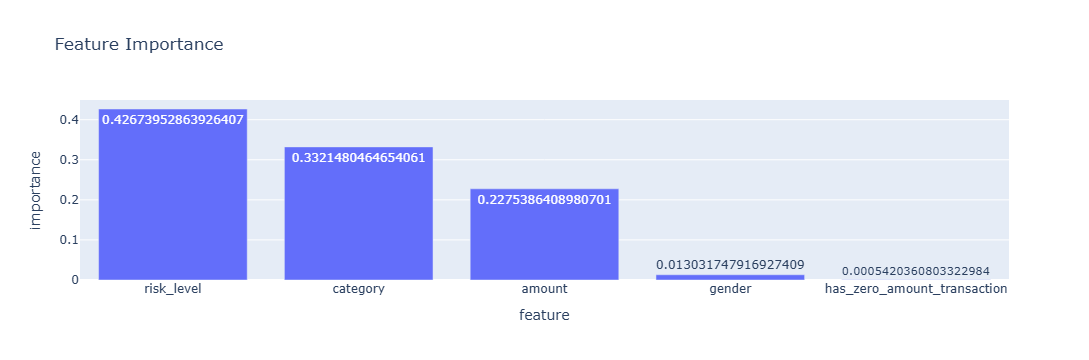

In [171]:
fig = px.bar(features_df,x='feature',y='importance',text='importance',title='Feature Importance')
fig.show()